# HW 4: Наилучшая среднеквадратичная линейная аппроксимация
### Задача III.5.11.в) Аппроксимация функции $f(x) = ln(1 + x)$ на $[0, 1]$

## Постановка задачи

Требуется построить наилучшую среднеквадратичную линейную аппроксимацию функции $\\f(x) = ln(1 + x)$ на отрезке $[0, 1]$ в виде: $F(x) = u_0 + u_1x$

In [ ]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [ ]:
# Функция для аппроксимации
def f(x):
    return np.log(1 + x)

# Базисные функции
def phi_0(x):
    return 1

def phi_1(x):
    return x

## Вычисление элементов матрицы Грама

In [ ]:
print("Вычисление элементов матрицы Грама:")

# Вычисление элементов матрицы Грама
phi00, _ = quad(lambda x: phi_0(x) * phi_0(x), 0, 1)
phi01, _ = quad(lambda x: phi_0(x) * phi_1(x), 0, 1)
phi11, _ = quad(lambda x: phi_1(x) * phi_1(x), 0, 1)

print(f"(φ₀, φ₀) = {phi00:.6f}")
print(f"(φ₀, φ₁) = (φ₁, φ₀) = {phi01:.6f}")
print(f"(φ₁, φ₁) = {phi11:.6f}")

Вычисление элементов матрицы Грама:
(φ₀, φ₀) = 1.000000
(φ₀, φ₁) = (φ₁, φ₀) = 0.500000
(φ₁, φ₁) = 0.333333


## Вычисление правой части системы

In [ ]:
print("\nВычисление правой части системы:")

# Вычисление правой части системы
f_phi0, _ = quad(lambda x: f(x) * phi_0(x), 0, 1)
f_phi1, _ = quad(lambda x: f(x) * phi_1(x), 0, 1)

print(f"(f, φ₀) = {f_phi0:.6f}")
print(f"(f, φ₁) = {f_phi1:.6f}")


Вычисление правой части системы:
(f, φ₀) = 0.386294
(f, φ₁) = 0.250000


## Решение системы уравнений

In [ ]:
# Формирование и решение системы уравнений
A = np.array([[phi00, phi01],
              [phi01, phi11]])
b = np.array([f_phi0, f_phi1])

print("Система уравнений:")
print(f"{A[0,0]:.2f}·u₀ + {A[0,1]:.2f}·u₁ = {b[0]:.6f}")
print(f"{A[1,0]:.2f}·u₀ + {A[1,1]:.2f}·u₁ = {b[1]:.6f}")

# Решение системы
u = np.linalg.solve(A, b)

print(f"\nКоэффициенты аппроксимации:")
print(f"u₀ = {u[0]:.6f}")
print(f"u₁ = {u[1]:.6f}")
print(f"\nАппроксимирующая функция: F(x) = {u[0]:.6f} + {u[1]:.6f}·x")

Система уравнений:
1.00·u₀ + 0.50·u₁ = 0.386294
0.50·u₀ + 0.33·u₁ = 0.250000

Коэффициенты аппроксимации:
u₀ = 0.045177
u₁ = 0.682234

Аппроксимирующая функция: F(x) = 0.045177 + 0.682234·x


## Визуализация результатов

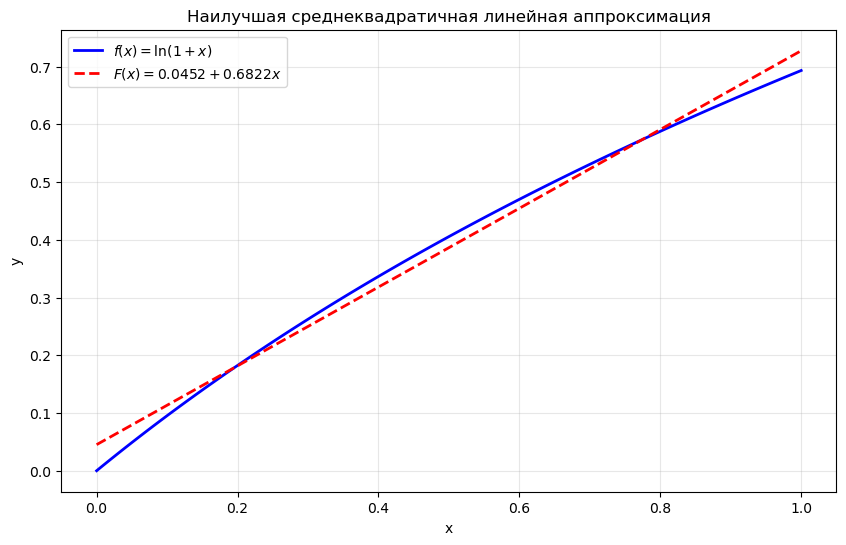

In [ ]:
# Визуализация результатов
x = np.linspace(0, 1, 100)
f_x = f(x)
F_x = u[0] + u[1] * x

plt.figure(figsize=(10, 6))
plt.plot(x, f_x, 'b-', linewidth=2, label='$f(x) = \\ln(1+x)$')
plt.plot(x, F_x, 'r--', linewidth=2, label=f'$F(x) = {u[0]:.4f} + {u[1]:.4f}x$')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Наилучшая среднеквадратичная линейная аппроксимация')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Анализ погрешности

In [ ]:
# Вычисление среднеквадратичной погрешности
def squared_error(x):
    return (u[0] + u[1] * x - f(x))**2

mse, _ = quad(squared_error, 0, 1)
rmse = np.sqrt(mse)

print("Анализ погрешности:")
print(f"Среднеквадратичная погрешность (MSE): {mse:.6f}")
print(f"Среднеквадратичное отклонение (RMSE): {rmse:.6f}")

# Погрешность в отдельных точках
test_points = [0, 0.25, 0.5, 0.75, 1]
print("\nПогрешность в отдельных точках:")
print(" x   | f(x)     | F(x)     | Погрешность")
print("-" * 40)
for x_point in test_points:
    f_val = f(x_point)
    F_val = u[0] + u[1] * x_point
    error = abs(F_val - f_val)
    print(f" {x_point:.2f} | {f_val:.6f} | {F_val:.6f} | {error:.6f}")

Анализ погрешности:
Среднеквадратичная погрешность (MSE): 0.000307
Среднеквадратичное отклонение (RMSE): 0.017523

Погрешность в отдельных точках:
 x   | f(x)     | F(x)     | Погрешность
----------------------------------------
 0.00 | 0.000000 | 0.045177 | 0.045177
 0.25 | 0.223144 | 0.215736 | 0.007408
 0.50 | 0.405465 | 0.386294 | 0.019171
 0.75 | 0.559616 | 0.556853 | 0.002763
 1.00 | 0.693147 | 0.727411 | 0.034264
